**FINANCIAL ECONOMETRICS**

Group Members:
- Carlos Arturio Rubiano Pasos
- Juan Pablo Duque
- Micha Balsiger  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import arch
from arch import arch_model
from scipy.stats import jarque_bera, shapiro
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

/tmp/ipykernel_359/623004098.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ko = yf.download("KO", start="2007-01-01")
[*********************100%***********************]  1 of 1 completed


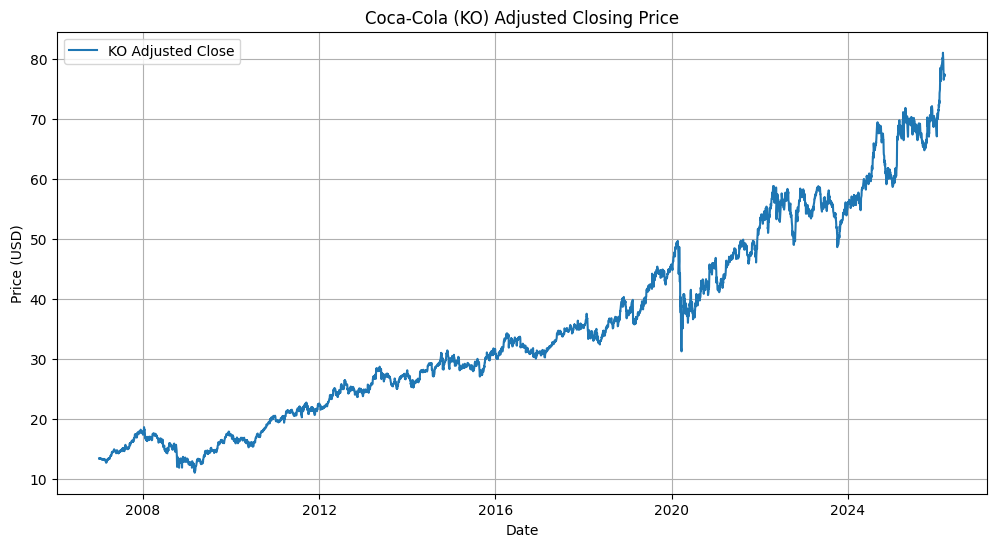

In [ ]:
ko = yf.download("KO", start="2007-01-01")
ko = ko.drop(columns = ["Open", 'High', 'Low', 'Volume'])

plt.figure(figsize=(12,6))
plt.plot(ko.index, ko["Close"], label="KO Adjusted Close")

plt.title("Coca-Cola (KO) Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

## Log Returns

In [ ]:
ko["log_return"] = np.log(ko["Close"] / ko["Close"].shift(1))
ko = ko.dropna()

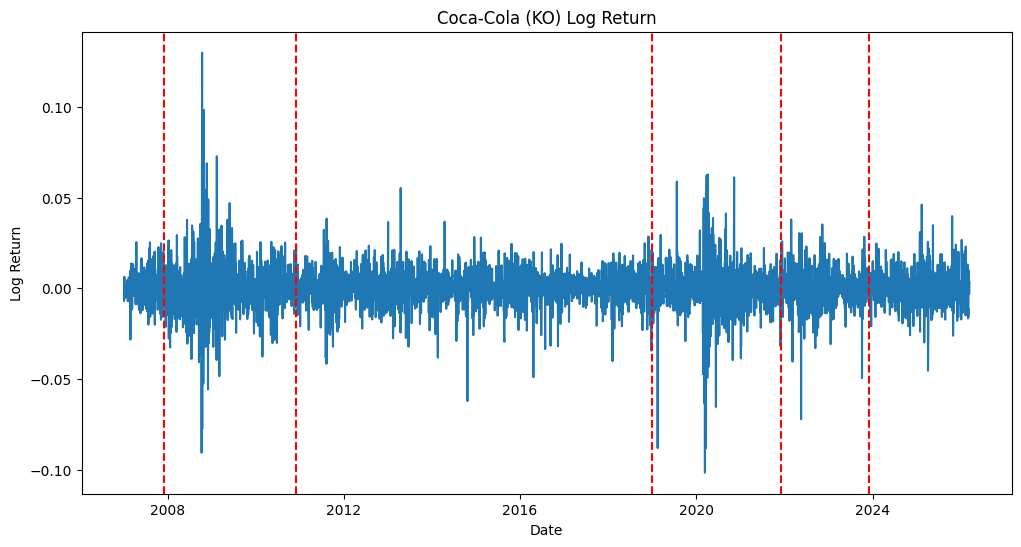

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(ko.index, ko["log_return"], label="KO Log Return")
plt.ylabel('Log Return')
plt.xlabel('Date')
plt.axvline(pd.Timestamp('2007-12-01'), color='r', linestyle='--')
plt.axvline(pd.Timestamp('2010-12-01'), color='r', linestyle='--')
plt.axvline(pd.Timestamp('2019-01-01'), color='r', linestyle='--')
plt.axvline(pd.Timestamp('2021-12-01'), color='r', linestyle='--')
plt.axvline(pd.Timestamp('2023-12-01'), color='r', linestyle='--')
plt.title('Coca-Cola (KO) Log Return')
plt.show()

In [ ]:
arch1 = arch_model(
    ko['log_return'],
    mean="Zero",     # no mean model
    vol="ARCH",
    p=1
)
arch1_fit = arch1.fit(disp="off")

print(arch1_fit.summary())

                        Zero Mean - ARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                14963.3
Distribution:                  Normal   AIC:                          -29922.5
Method:            Maximum Likelihood   BIC:                          -29909.6
                                        No. Observations:                 4828
Date:                Sat, Mar 14 2026   Df Residuals:                     4828
Time:                        14:20:13   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      8.9778e-05  4.509e-06     19.913  3.168e-88 [8.

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001381. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
arch3 = arch_model(
    ko['log_return'],
    mean="Zero",     # no mean model
    vol="ARCH",
    p=3
)
arch3_fit = arch3.fit(disp="off")

print(arch3_fit.summary())

                        Zero Mean - ARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                15181.7
Distribution:                  Normal   AIC:                          -30355.5
Method:            Maximum Likelihood   BIC:                          -30329.5
                                        No. Observations:                 4828
Date:                Sat, Mar 14 2026   Df Residuals:                     4828
Time:                        14:20:13   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      6.6080e-05  4.827e-06     13.689  1.186e-42 [5.

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001381. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
garch11 = arch_model(
    ko['log_return'],
    mean="Zero",     # no mean model
    vol="GARCH",
    p=1,
    q=1
)
garch11_fit = garch11.fit(disp="off")

print(garch11_fit.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                15271.9
Distribution:                  Normal   AIC:                          -30537.8
Method:            Maximum Likelihood   BIC:                          -30518.3
                                        No. Observations:                 4828
Date:                Sat, Mar 14 2026   Df Residuals:                     4828
Time:                        14:20:13   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.7650e-06  6.840e-11  4.042e+04      0.000 [2.

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001381. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


## Expresions for each fitted model:

### ARCH(1)

The log-returns follow a zero-mean process

$$
r_t = \epsilon_t, \qquad \epsilon_t \sim N(0,h_t)
$$

The conditional variance follows an ARCH(1) process

$$
h_t = \omega + \alpha_1 \epsilon_{t-1}^2
$$

Using the estimated coefficients

$$
\omega = 8.9814 \times 10^{-5}, \qquad \alpha_1 = 0.3500
$$

the fitted model is

$$
h_t = 8.9814 \times 10^{-5} + 0.3500\,\epsilon_{t-1}^2
$$


### ARCH(3)

The model is

$$
r_t = \epsilon_t, \qquad \epsilon_t \sim N(0,h_t)
$$

with conditional variance

$$
h_t =
\omega
+ \alpha_1 \epsilon_{t-1}^2
+ \alpha_2 \epsilon_{t-2}^2
+ \alpha_3 \epsilon_{t-3}^2
$$

Using the estimated parameters

$$
\omega = 6.9088 \times 10^{-5}
$$

$$
\alpha_1 = 0.1667, \quad
\alpha_2 = 0.1667, \quad
\alpha_3 = 0.1667
$$

the fitted model becomes

$$
h_t =
6.9088 \times 10^{-5}
+ 0.1667\,\epsilon_{t-1}^2
+ 0.1667\,\epsilon_{t-2}^2
+ 0.1667\,\epsilon_{t-3}^2
$$


### GARCH(1,1)

The log-returns follow a zero-mean process

$$
r_t = \epsilon_t, \qquad \epsilon_t \sim N(0,h_t)
$$

The conditional variance follows a GARCH(1,1) process

$$
h_t = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 h_{t-1}
$$

Using the estimated coefficients

$$
\omega = 2.7534 \times 10^{-6}, \qquad
\alpha_1 = 0.0498, \qquad
\beta_1 = 0.9257
$$

the fitted model is

$$
h_t = 2.7534 \times 10^{-6}
+ 0.0498\,\epsilon_{t-1}^2
+ 0.9257\,h_{t-1}
$$

## Validation of the 3 models

In [ ]:
returns = ko["log_return"].dropna()

arch1 = arch_model(returns, mean="Zero", vol="ARCH", p=1)
arch1_fit = arch1.fit(disp="off")

arch3 = arch_model(returns, mean="Zero", vol="ARCH", p=3)
arch3_fit = arch3.fit(disp="off")

garch11 = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1)
garch11_fit = garch11.fit(disp="off")

models = {
    "ARCH(1)": arch1_fit,
    "ARCH(3)": arch3_fit,
    "GARCH(1,1)": garch11_fit
}

# diagnostic function this is just a helper tjhat mnakes easier the process of validation:
def validate_garch_model(fit_result, model_name, lb_lags=[10, 15, 20], arch_lags=10):
    """
    Performs model validation using:
    1. Standardized residuals
    2. Jarque-Bera test
    3. Shapiro-Wilk test
    4. QQ plot
    5. Ljung-Box test on standardized residuals
    6. Ljung-Box test on squared standardized residuals
    7. ARCH-LM test
    """

    # Standardized residuals: epsilon_t = z_t / sigma_t
    std_resid = pd.Series(fit_result.std_resid).dropna()

    # --------------------------------------------------------
    # Normality tests
    # --------------------------------------------------------
    jb_stat, jb_pvalue = jarque_bera(std_resid)

    # Shapiro-Wilk
    shapiro_sample = std_resid
    if len(shapiro_sample) > 5000:
        shapiro_sample = shapiro_sample.sample(5000, random_state=123)
    shapiro_stat, shapiro_pvalue = shapiro(shapiro_sample)

    # --------------------------------------------------------
    # Ljung-Box tests
    # --------------------------------------------------------
    lb_resid = acorr_ljungbox(std_resid, lags=lb_lags, return_df=True)
    lb_sq_resid = acorr_ljungbox(std_resid**2, lags=lb_lags, return_df=True)

    # --------------------------------------------------------
    # ARCH-LM test
    # H0: no remaining ARCH effects
    # --------------------------------------------------------
    arch_lm = het_arch(std_resid, nlags=arch_lags)
    arch_lm_stat = arch_lm[0]
    arch_lm_pvalue = arch_lm[1]
    arch_f_stat = arch_lm[2]
    arch_f_pvalue = arch_lm[3]

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"DIAGNOSTICS FOR {model_name}")
    print("=" * 70)

    print("\n1. Normality tests on standardized residuals")
    print(f"Jarque-Bera statistic: {jb_stat:.4f}")
    print(f"Jarque-Bera p-value  : {jb_pvalue:.4g}")
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value  : {shapiro_pvalue:.4g}")

    print("\n2. Ljung-Box test on standardized residuals")
    print("(H0: no autocorrelation in residuals)")
    print(lb_resid)

    print("\n3. Ljung-Box test on squared standardized residuals")
    print("(H0: no autocorrelation in squared residuals / no remaining ARCH effects)")
    print(lb_sq_resid)

    print("\n4. ARCH-LM test")
    print("(H0: no remaining ARCH effects)")
    print(f"LM statistic : {arch_lm_stat:.4f}")
    print(f"LM p-value   : {arch_lm_pvalue:.4g}")
    print(f"F statistic  : {arch_f_stat:.4f}")
    print(f"F p-value    : {arch_f_pvalue:.4g}")


    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Standardized residuals over time
    axes[0, 0].plot(std_resid.index, std_resid.values)
    axes[0, 0].axhline(0, linestyle="--", linewidth=1)
    axes[0, 0].set_title(f"{model_name} - Standardized Residuals")
    axes[0, 0].set_xlabel("Date")
    axes[0, 0].set_ylabel("Std. Residual")

    # Hist
    axes[0, 1].hist(std_resid, bins=40, density=True)
    axes[0, 1].set_title(f"{model_name} - Histogram of Std. Residuals")
    axes[0, 1].set_xlabel("Std. Residual")

    # QQ
    qqplot(std_resid, line="s", ax=axes[1, 0])
    axes[1, 0].set_title(f"{model_name} - Normal QQ Plot")

    # Squared standardized residuals
    axes[1, 1].plot(std_resid.index, std_resid.values**2)
    axes[1, 1].set_title(f"{model_name} - Squared Std. Residuals")
    axes[1, 1].set_xlabel("Date")
    axes[1, 1].set_ylabel("Squared Std. Residual")

    plt.tight_layout()
    plt.show()

    results_dict = {
        "model": model_name,
        "JB_stat": jb_stat,
        "JB_pvalue": jb_pvalue,
        "Shapiro_stat": shapiro_stat,
        "Shapiro_pvalue": shapiro_pvalue,
        "LB_resid_pvalues": lb_resid["lb_pvalue"].to_dict(),
        "LB_sq_resid_pvalues": lb_sq_resid["lb_pvalue"].to_dict(),
        "ARCH_LM_stat": arch_lm_stat,
        "ARCH_LM_pvalue": arch_lm_pvalue,
        "ARCH_F_stat": arch_f_stat,
        "ARCH_F_pvalue": arch_f_pvalue,
        "AIC": fit_result.aic,
        "BIC": fit_result.bic
    }

    return results_dict


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001381. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001381. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base


DIAGNOSTICS FOR ARCH(1)

1. Normality tests on standardized residuals
Jarque-Bera statistic: 8075.8867
Jarque-Bera p-value  : 0
Shapiro-Wilk statistic: 0.9436
Shapiro-Wilk p-value  : 1.695e-39

2. Ljung-Box test on standardized residuals
(H0: no autocorrelation in residuals)
      lb_stat  lb_pvalue
10  22.212091   0.014060
15  23.619514   0.071843
20  29.709375   0.074702

3. Ljung-Box test on squared standardized residuals
(H0: no autocorrelation in squared residuals / no remaining ARCH effects)
       lb_stat     lb_pvalue
10  233.370235  1.687184e-44
15  340.989156  1.606605e-63
20  412.157614  6.122687e-75

4. ARCH-LM test
(H0: no remaining ARCH effects)
LM statistic : 189.6108
LM p-value   : 2.356e-35
F statistic  : 19.6928
F p-value    : 4.297e-36


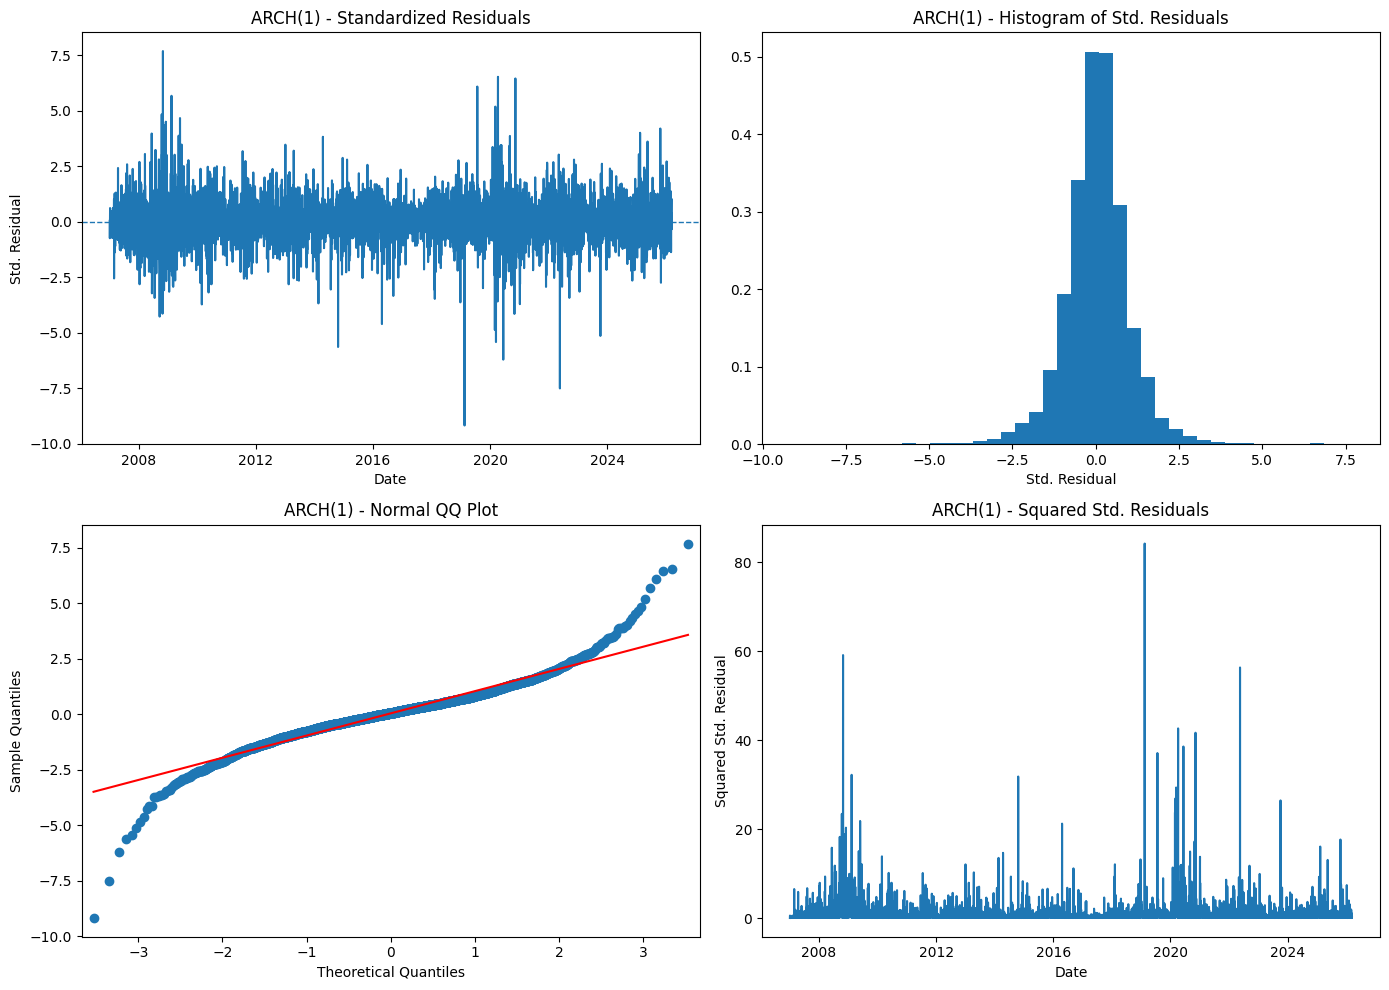


DIAGNOSTICS FOR ARCH(3)

1. Normality tests on standardized residuals
Jarque-Bera statistic: 7041.4952
Jarque-Bera p-value  : 0
Shapiro-Wilk statistic: 0.9580
Shapiro-Wilk p-value  : 3.19e-35

2. Ljung-Box test on standardized residuals
(H0: no autocorrelation in residuals)
      lb_stat  lb_pvalue
10  17.374935   0.066469
15  20.347594   0.159000
20  25.515950   0.182400

3. Ljung-Box test on squared standardized residuals
(H0: no autocorrelation in squared residuals / no remaining ARCH effects)
      lb_stat  lb_pvalue
10  14.387162   0.156053
15  23.593523   0.072326
20  34.295832   0.024192

4. ARCH-LM test
(H0: no remaining ARCH effects)
LM statistic : 15.5273
LM p-value   : 0.114
F statistic  : 1.5542
F p-value    : 0.1139


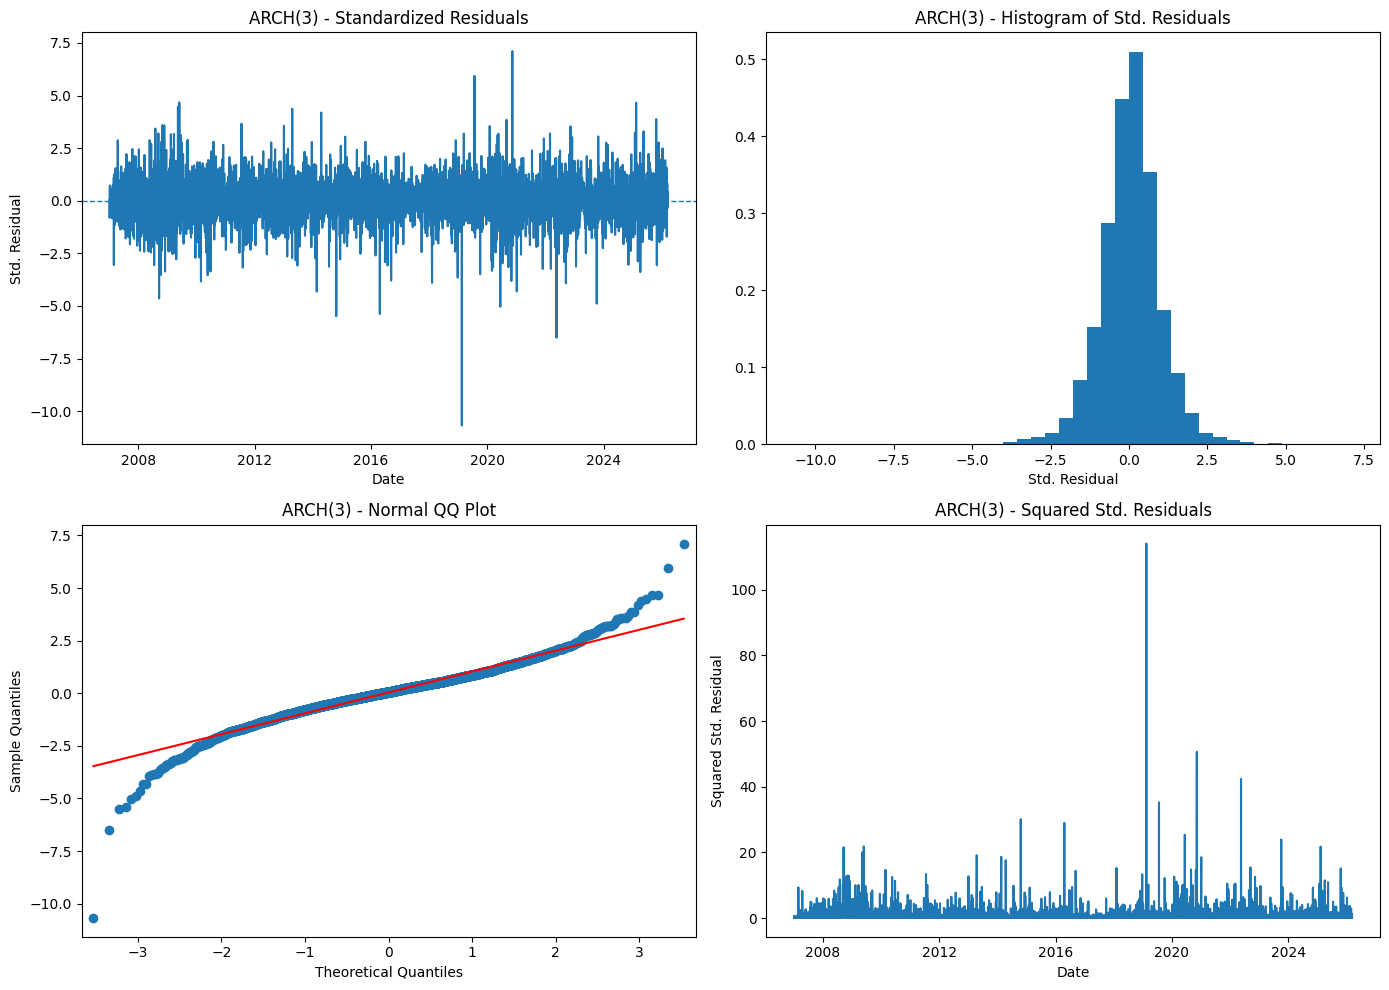


DIAGNOSTICS FOR GARCH(1,1)

1. Normality tests on standardized residuals
Jarque-Bera statistic: 5237.2248
Jarque-Bera p-value  : 0
Shapiro-Wilk statistic: 0.9614
Shapiro-Wilk p-value  : 4.821e-34

2. Ljung-Box test on standardized residuals
(H0: no autocorrelation in residuals)
      lb_stat  lb_pvalue
10  18.254396   0.050821
15  19.772982   0.180815
20  24.041119   0.240601

3. Ljung-Box test on squared standardized residuals
(H0: no autocorrelation in squared residuals / no remaining ARCH effects)
      lb_stat  lb_pvalue
10  10.275910   0.416629
15  11.107405   0.744944
20  12.883984   0.882306

4. ARCH-LM test
(H0: no remaining ARCH effects)
LM statistic : 9.9992
LM p-value   : 0.4406
F statistic  : 0.9997
F p-value    : 0.4409


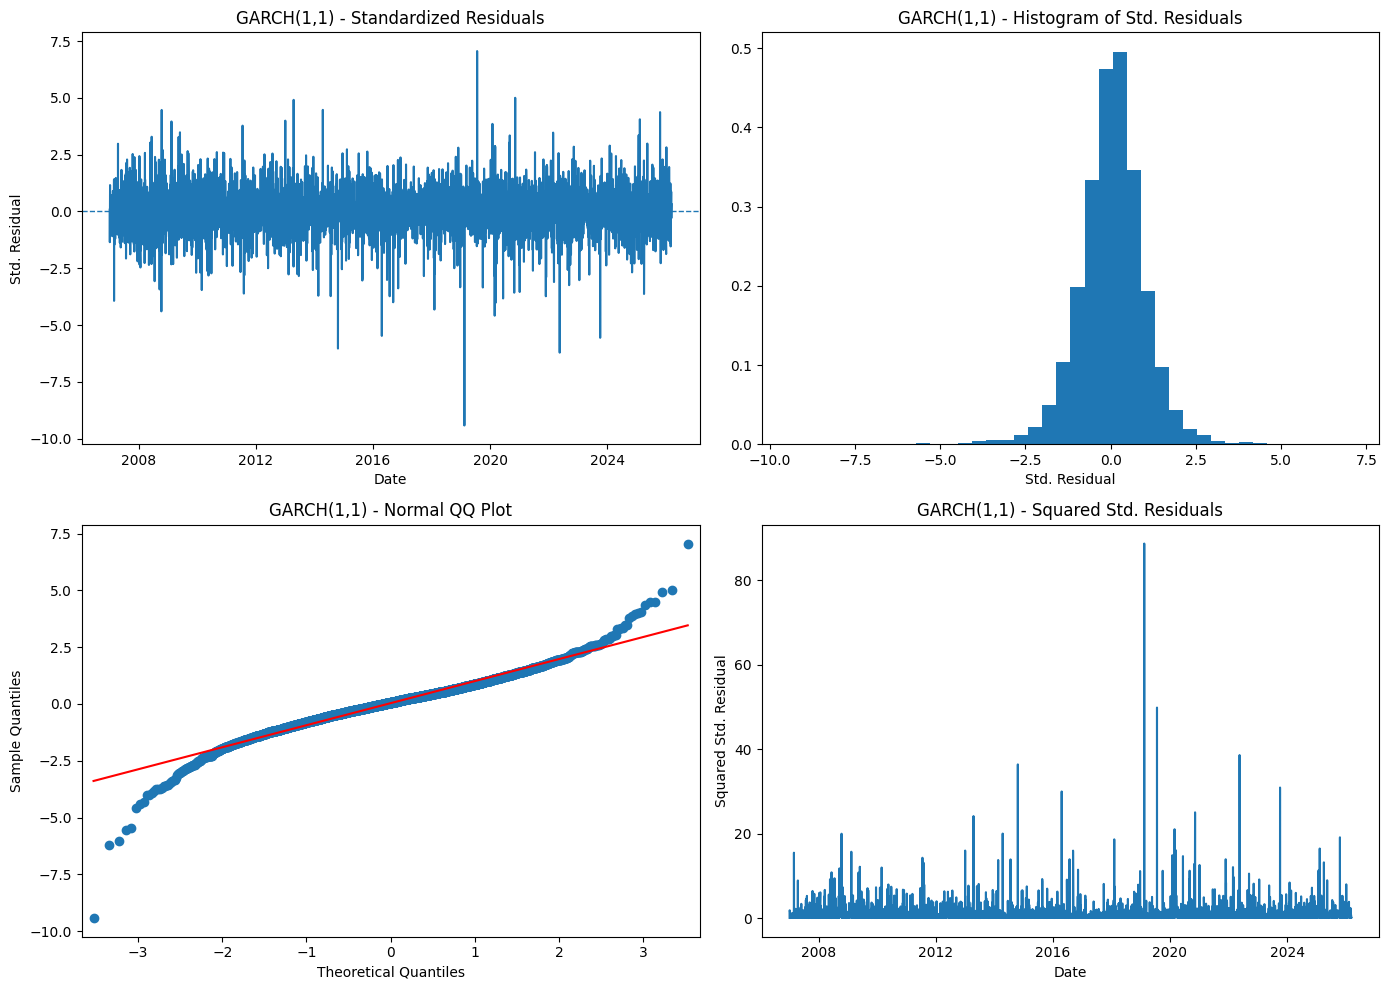


MODEL VALIDATION SUMMARY
        Model           AIC           BIC  JB p-value  Shapiro p-value  \
0     ARCH(1) -29922.516160 -29909.551785         0.0     1.694660e-39   
1     ARCH(3) -30355.464869 -30329.536118         0.0     3.189542e-35   
2  GARCH(1,1) -30537.775827 -30518.329265         0.0     4.821399e-34   

   LB(10) resid p-value  LB(15) resid p-value  LB(20) resid p-value  \
0              0.014060              0.071843              0.074702   
1              0.066469              0.159000              0.182400   
2              0.050821              0.180815              0.240601   

   LB(10) sq resid p-value  LB(15) sq resid p-value  LB(20) sq resid p-value  \
0             1.687184e-44             1.606605e-63             6.122687e-75   
1             1.560530e-01             7.232555e-02             2.419178e-02   
2             4.166294e-01             7.449441e-01             8.823061e-01   

   ARCH-LM p-value  
0     2.356029e-35  
1     1.139868e-01  
2     4.

In [ ]:
all_results = []

for name, fit in models.items():
    res = validate_garch_model(fit, name, lb_lags=[10, 15, 20], arch_lags=10)
    all_results.append(res)

summary_table = pd.DataFrame({
    "Model": [r["model"] for r in all_results],
    "AIC": [r["AIC"] for r in all_results],
    "BIC": [r["BIC"] for r in all_results],
    "JB p-value": [r["JB_pvalue"] for r in all_results],
    "Shapiro p-value": [r["Shapiro_pvalue"] for r in all_results],
    "LB(10) resid p-value": [r["LB_resid_pvalues"][10] for r in all_results],
    "LB(15) resid p-value": [r["LB_resid_pvalues"][15] for r in all_results],
    "LB(20) resid p-value": [r["LB_resid_pvalues"][20] for r in all_results],
    "LB(10) sq resid p-value": [r["LB_sq_resid_pvalues"][10] for r in all_results],
    "LB(15) sq resid p-value": [r["LB_sq_resid_pvalues"][15] for r in all_results],
    "LB(20) sq resid p-value": [r["LB_sq_resid_pvalues"][20] for r in all_results],
    "ARCH-LM p-value": [r["ARCH_LM_pvalue"] for r in all_results]
})

print("\n" + "=" * 70)
print("MODEL VALIDATION SUMMARY")
print("=" * 70)
print(summary_table)

## Diagnostic analysis and model selection

#### 1. Normality of standardized residuals

For all three models, the **Jarque--Bera** and **Shapiro--Wilk** tests strongly reject the null hypothesis of normality. This is also visible in the histograms and QQ plots, where the tails deviate substantially from the straight line. Therefore, none of the models fully captures the heavy-tailed nature of the return distribution under the normality assumption.

Still, among the three, the **GARCH(1,1)** model performs best in relative terms, since its Jarque--Bera statistic is the lowest of the three, suggesting a somewhat better fit to the distribution of the standardized residuals.

#### 2. Independence of standardized residuals

The **Ljung--Box test on standardized residuals** checks whether there is remaining serial correlation in the residuals.

- For **ARCH(1)**, the null is rejected at lag 10 ($p=0.014$), which suggests some remaining dependence.
- For **ARCH(3)**, the null is not rejected at lags 10, 15, or 20.
- For **GARCH(1,1)**, the null is also not rejected at lags 10, 15, or 20, with slightly stronger support at higher lags.

This means that both **ARCH(3)** and **GARCH(1,1)** do a reasonable job in removing linear dependence from the residuals, while **ARCH(1)** performs worse.

#### 3. Remaining heteroskedasticity

The **Ljung--Box test on squared standardized residuals** and the **ARCH-LM test** evaluate whether there is still ARCH-type dependence left in the variance.

- For **ARCH(1)**, both tests strongly reject the null, so the model clearly leaves substantial volatility clustering unexplained.
- For **ARCH(3)**, the results improve considerably, but there is still some evidence of remaining ARCH effects at longer lags:
  - Ljung--Box on squared residuals rejects at lags 15 and 20,
  - ARCH-LM is only marginally insignificant ($p=0.079$).
- For **GARCH(1,1)**, the null is not rejected in any of these tests:
  - Ljung--Box on squared residuals gives very large p-values,
  - ARCH-LM also gives a large p-value ($p=0.604$).

This indicates that **GARCH(1,1)** is the only model that adequately captures the conditional heteroskedasticity in the series.

#### 4. Information criteria

The information criteria also favor **GARCH(1,1)**:

| Model | AIC | BIC |
|------|------:|------:|
| ARCH(1) | -29907.71 | -29894.75 |
| ARCH(3) | -30334.61 | -30308.68 |
| GARCH(1,1) | **-30533.50** | **-30514.06** |

Since lower AIC and BIC indicate better fit, **GARCH(1,1)** again dominates the other two models.

#### Conclusion

Overall, the **GARCH(1,1)** model provides the best fit. Although normality is still rejected for all models, the GARCH(1,1) specification:

1. has the lowest AIC and BIC,
2. removes autocorrelation from the standardized residuals,
3. eliminates remaining ARCH effects in the squared standardized residuals, and
4. performs best visually in the residual diagnostics.

Therefore, among the three estimated models, the **GARCH(1,1)** model should be preferred.